In [1]:
import pandas as pd
pd.set_option('display.max_colwidth', None)
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import MultiLabelBinarizer,  StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import accuracy_score
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
from tqdm import tqdm
from sklearn.model_selection import StratifiedKFold
tqdm.pandas(desc="Processing Rows")
import os
import joblib
import gc
import time
import numpy as np
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader
import ast
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import SGDClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    r2_score
)
from sklearn.decomposition import PCA
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF
import seaborn as sns
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
hf_token = "os.environ['HF_TOKEN']" 

/apps/common/software/Miniforge3/25.11.0-1-jupyter-base/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
model_id = "/common/data/models/qwen--Qwen3-14B"
from transformers import AutoTokenizer, AutoModelForCausalLM

hf_token = "os.environ['HF_TOKEN']" 

tokenizer = AutoTokenizer.from_pretrained(model_id,token=hf_token)
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    torch_dtype=torch.bfloat16,
    device_map="auto",
    token=hf_token
)

`torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|██████████| 443/443 [00:02<00:00, 206.45it/s]
Some parameters are on the meta device because they were offloaded to the cpu.


In [3]:

df=pd.read_csv("../Datasets/World_Ecological_2015_Metadata.csv")

columns = [
    'geonameid', 'name', 'asciiname', 'alternatenames', 
    'latitude', 'longitude', 'feature_class', 'feature_code', 
    'country_code', 'cc2', 'admin1', 'admin2', 'admin3', 'admin4', 
    'population', 'elevation', 'dem', 'timezone', 'modification_date'
]

df_geo = pd.read_csv('../Datasets/allCountries.txt', sep='\t', names=columns, low_memory=False)
df_landforms = df_geo[df_geo['feature_class'] == 'T']
combined_dataset=pd.read_csv("../Datasets/Global_Named_Landforms_With_Labels.csv")
combined_dataset=combined_dataset[['name','alternatenames','feature_code','ELU_LF_Des']]
exact_6_class_map = {
    # 1: Plains
    'PLN': 1, 'PLNS': 1, 'FLT': 1, 'PANS': 1,
    
    # 2: Hills and Low Tablelands
    'HLL': 2, 'HLLS': 2, 'MND': 2, 'KNOB': 2,
    
    # 3: High Tablelands
    'PT': 3, 'PLAT': 3, 'MESA': 3, 'BUTT': 3,
    
    # 4: Ridges
    'RDG': 4, 'RDGS': 4, 'SADL': 4, 'DUNE': 4,
    
    # 5: Widely Spaced Mountains
    'MT': 5, 'MTS': 5, 'PK': 5, 'PKS': 5, 'CONE': 5, 'VOLC': 5, 'NUP': 5, 'RK': 5,
    
    # 7: Depressions or Basins
    'BSN': 7, 'BSNS': 7, 'DPR': 7, 'SINK': 7, 'CRQS': 7, 'CRATER': 7
}

combined_dataset['macro_class_id'] = combined_dataset['feature_code'].map(exact_6_class_map)
combined_dataset = combined_dataset.dropna(subset=['macro_class_id'])
combined_dataset['macro_class_id'] = combined_dataset['macro_class_id'].astype(int)
combined_dataset=combined_dataset[~combined_dataset['macro_class_id'].isna()]
combined_dataset=combined_dataset[['name','macro_class_id']]
combined_dataset.columns=['Bridges Full Name','Topographic']
combined_dataset = combined_dataset.groupby('Bridges Full Name')['Topographic'].apply(lambda x: list(set(x))).reset_index()
ascii_mask = combined_dataset['Bridges Full Name'].astype(str).str.contains(r'^[\x00-\x7F]+$')
combined_dataset = combined_dataset[ascii_mask].reset_index(drop=True)
combined_dataset

/localscratch/481477/ipykernel_1060607/1853054812.py:12: DtypeWarning: Columns (9,10,11,12,13) have mixed types. Specify dtype option on import or set low_memory=False.
  combined_dataset=pd.read_csv("../Datasets/Global_Named_Landforms_With_Labels.csv")


,Bridges Full Name,Topographic
0,'Adade Yus Mountain,[5]
1,'Aqabat Nikid,[5]
2,'Elb Chouf,[4]
3,'Elb ech Chaoufa,[4]
4,'S Airde Beinn,[2]
...,...,...
618599,wzgorze na Katarynkach,[2]
618600,wzgorze nad Tuchlinkiem,[2]
618601,yak Gawa,[5]
618602,ytre Midtberget,[2]


In [4]:
combined_dataset.iloc[1000:1040]

,Bridges Full Name,Topographic
1000,Ach-Chaqra,[5]
1001,Ach-Chgigat Al Lwilbat,[2]
1002,Acha,[5]
1003,Acha Rock,[5]
1004,Achab Alhoumre,[2]
1005,Achab se Berge,[2]
1006,Achaboi,[2]
1007,Achacanani Pampa,[1]
1008,Achachked,[5]
1009,Achada Bargado,[3]


In [5]:
def label_to_list(x):
    if isinstance(x, np.ndarray):
        return [int(v) for v in x.tolist()]

    if isinstance(x, (list, tuple)):
        return [int(v) for v in x]

    if isinstance(x, str):
        x = x.strip()
        if x.startswith("["):
            return [int(v) for v in ast.literal_eval(x)]
        return [int(float(x))]

    return [int(x)]


X = combined_dataset["Bridges Full Name"].astype(str)
y_labels = combined_dataset["Topographic"].apply(label_to_list)

# optional: stratify by exact label-combination string
y_combo = y_labels.apply(lambda z: tuple(sorted(z)))

X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(
    X,
    y_labels,
    test_size=0.20,
    stratify=None,
    random_state=42
)
MAX_TRAIN = 100000
MAX_TEST = 20000

train_combo = y_train_full.apply(lambda z: tuple(sorted(z)))
test_combo = y_test_full.apply(lambda z: tuple(sorted(z)))

X_train_list, _, y_train_labels, _ = train_test_split(
    X_train_full.tolist(),
    y_train_full.tolist(),
    train_size=min(MAX_TRAIN, len(X_train_full)),
    stratify=None,
    random_state=42
)

X_test_list, _, y_test_labels, _ = train_test_split(
    X_test_full.tolist(),
    y_test_full.tolist(),
    train_size=min(MAX_TEST, len(X_test_full)),
    stratify=None,
    random_state=42
)

mlb = MultiLabelBinarizer()
Y_train = mlb.fit_transform(y_train_labels)
Y_test = mlb.transform(y_test_labels)

print("Classes:", mlb.classes_)
print("Y_train shape:", Y_train.shape)
print("Y_test shape:", Y_test.shape)

Classes: [1 2 3 4 5 7]
Y_train shape: (100000, 6)
Y_test shape: (20000, 6)


In [6]:


torch.cuda.empty_cache()
BATCH_SIZE = 64
MAX_LEN = 64

num_blocks = len(model.model.layers)
print("Transformer blocks:", num_blocks)
HIDDEN_STATE_LAYERS = [i for i in range(0,num_blocks+1,4)]


if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

tokenizer.padding_side = "right"

model.eval()
model.config.use_cache = False

if hasattr(model, "gradient_checkpointing_disable"):
    model.gradient_checkpointing_disable()

train_loader = DataLoader(
    X_train_list,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)

test_loader = DataLoader(
    X_test_list,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)
# first extract layers
def extract_selected_token_states(loader, desc, hidden_state_layers):
    chunks = {l: [] for l in hidden_state_layers}

    with torch.inference_mode():
        for batch in tqdm(loader, desc=desc):
            inputs = tokenizer(
                list(batch),
                padding=True,
                truncation=True,
                max_length=MAX_LEN,
                return_tensors="pt"
            ).to(model.device)
            lengths = inputs["attention_mask"].sum(dim=1) - 1
            batch_idx = torch.arange(inputs["input_ids"].shape[0], device=model.device)

            with torch.inference_mode():
                outputs = model(
                    **inputs,
                    output_hidden_states=True,
                    use_cache=False
                )

            for l in hidden_state_layers:
                hs = outputs.hidden_states[l]
                tok_state = hs[batch_idx, lengths, :]
                chunks[l].append(tok_state.float().cpu().numpy().astype(np.float32))

            del inputs, outputs, lengths, batch_idx, tok_state
            gc.collect()

    return {l: np.vstack(chunks[l]) for l in hidden_state_layers}

start = time.perf_counter()

print("\nExtracting train hidden states...")
train_cache = extract_selected_token_states(train_loader, "Train", HIDDEN_STATE_LAYERS)

print("\nExtracting test hidden states...")
test_cache = extract_selected_token_states(test_loader, "Test", HIDDEN_STATE_LAYERS)

print(f"\nExtraction time: {(time.perf_counter() - start) / 60:.2f} min")



Transformer blocks: 40

Extracting train hidden states...


Train: 100%|██████████| 1563/1563 [44:33<00:00,  1.71s/it]



Extracting test hidden states...


Test: 100%|██████████| 313/313 [08:56<00:00,  1.71s/it]



Extraction time: 53.69 min


In [7]:
# import pickle

# with open("train_cache.pkl", "wb") as f:
#     pickle.dump(train_cache, f)

# with open("test_cache.pkl", "wb") as f:
#     pickle.dump(test_cache, f)
# with open("labels.pkl", "wb") as f:
#     pickle.dump({
#         "Y_train": Y_train,
#         "Y_test": Y_test
#     }, f)

In [8]:
# import pickle

# with open("train_cache.pkl", "rb") as f:
#     train_cache = pickle.load(f)

# with open("test_cache.pkl", "rb") as f:
#     test_cache = pickle.load(f)

# with open("labels.pkl", "rb") as f:
#     labels = pickle.load(f)

# Y_train = labels["Y_train"]
# Y_test = labels["Y_test"]

In [9]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import (
    RBF,
    ConstantKernel,
    WhiteKernel,
)
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    average_precision_score,
)

REP_LAYER = 36
COMPONENTS = 32
N = 5000
RANDOM_STATE = 42

Xtr = np.asarray(train_cache[REP_LAYER])
Xte = np.asarray(test_cache[REP_LAYER])

rng = np.random.default_rng(RANDOM_STATE)

train_idx = rng.choice(
    len(Xtr),
    size=min(N, len(Xtr)),
    replace=False,
)

test_idx = rng.choice(
    len(Xte),
    size=min(N, len(Xte)),
    replace=False,
)

Xtr_small = Xtr[train_idx]
Ytr_small = np.asarray(Y_train)[train_idx]

Xte_small = Xte[test_idx]
Yte_small = np.asarray(Y_test)[test_idx]

# Learn PCA only from training data.
pca = PCA(
    n_components=COMPONENTS,
    random_state=RANDOM_STATE,
)

Xtr_pca = pca.fit_transform(Xtr_small)
Xte_pca = pca.transform(Xte_small)

# Put PCA components on comparable scales.
scaler = StandardScaler()
Xtr_gp = scaler.fit_transform(Xtr_pca)
Xte_gp = scaler.transform(Xte_pca)

gps = {}
gp_results = []

for col_idx, raw_label in enumerate(mlb.classes_):
    print(f"\nTraining GP for {raw_label}")

    ytr = Ytr_small[:, col_idx].astype(float)
    yte = Yte_small[:, col_idx].astype(int)

    if np.unique(ytr).size < 2:
        print("Skipped: the training subset does not contain both classes.")
        continue

    kernel = (
        ConstantKernel(1.0, (1e-2, 1e2))
        * RBF(1.0, (1e-2, 1e2))
        + WhiteKernel(0.1, (1e-5, 1e1))
    )

    gpr = GaussianProcessRegressor(
        kernel=kernel,
        normalize_y=True,
        alpha=1e-6,
        random_state=RANDOM_STATE,
    )

    gpr.fit(Xtr_gp, ytr)

    score, uncertainty = gpr.predict(
        Xte_gp,
        return_std=True,
    )

    prediction = (score >= 0.5).astype(int)
    correct = prediction == yte

    result = {
        "raw_label": raw_label,
        "column": col_idx,
        "positive_count": int(yte.sum()),
        "positive_rate": float(yte.mean()),
        "accuracy": accuracy_score(yte, prediction),
        "f1": f1_score(yte, prediction, zero_division=0),
        "precision": precision_score(
            yte, prediction, zero_division=0
        ),
        "recall": recall_score(
            yte, prediction, zero_division=0
        ),
        "score_mean": float(score.mean()),
        "uncertainty_mean": float(uncertainty.mean()),
        "uncertainty_correct": (
            float(uncertainty[correct].mean())
            if correct.any()
            else np.nan
        ),
        "uncertainty_incorrect": (
            float(uncertainty[~correct].mean())
            if (~correct).any()
            else np.nan
        ),
    }

    # These metrics require both classes in the test subset.
    if np.unique(yte).size == 2:
        result["roc_auc"] = roc_auc_score(yte, score)
        result["average_precision"] = average_precision_score(
            yte, score
        )
    else:
        result["roc_auc"] = np.nan
        result["average_precision"] = np.nan

    gps[raw_label] = gpr
    gp_results.append(result)

    print("Learned kernel:", gpr.kernel_)
    print("F1:", result["f1"])
    print("Average precision:", result["average_precision"])
    print(
        "Average uncertainty on incorrect predictions:",
        result["uncertainty_incorrect"],
    )

gp_results_df = pd.DataFrame(gp_results)

best_layer = REP_LAYER
best_pca = pca
best_scaler = scaler
best_gps = gps


Training GP for 1


/home/ravim/.local/lib/python3.14/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


Learned kernel: 1.01**2 * RBF(length_scale=1.76) + WhiteKernel(noise_level=1e-05)
F1: 0.6571428571428571
Average precision: 0.7007760841404927
Average uncertainty on incorrect predictions: 0.12206231979611647

Training GP for 2
Learned kernel: 0.596**2 * RBF(length_scale=3.58) + WhiteKernel(noise_level=0.647)
F1: 0.631307929969104
Average precision: 0.7373968183990335
Average uncertainty on incorrect predictions: 0.42054026978283776

Training GP for 3
Learned kernel: 0.832**2 * RBF(length_scale=3.46) + WhiteKernel(noise_level=0.31)
F1: 0.7371727748691099
Average precision: 0.8053146942165713
Average uncertainty on incorrect predictions: 0.2102708850156277

Training GP for 4
Learned kernel: 0.954**2 * RBF(length_scale=1.77) + WhiteKernel(noise_level=0.16)
F1: 0.34285714285714286
Average precision: 0.3122415467974604
Average uncertainty on incorrect predictions: 0.07984298118469689

Training GP for 5
Learned kernel: 0.626**2 * RBF(length_scale=4.33) + WhiteKernel(noise_level=0.637)
F1: 0

In [10]:
X = test_cache[best_layer]
if torch.is_tensor(X): X = X.detach().cpu().numpy()
l=[]
Z = best_scaler.transform(best_pca.transform(X))
rng = np.random.default_rng(42)
df=dict()
cols=[]
for label, gp in best_gps.items():
    df[f"Label {label}"]=dict()
    
    for i in [0, 10, 15, 25, 100, 150, 200]:
        z0 = Z[i]
        df[f"Label {label}"][str(i)]=dict()
        dirs = rng.normal(size=(1000, z0.size))
        dirs /= np.linalg.norm(dirs, axis=1, keepdims=True)

        candidates = z0 + dirs
        means, stds = gp.predict(candidates, return_std=True)
        direction = dirs[np.argmax(means - 0.5 * stds)]

        m0, s0 = gp.predict(z0[None], return_std=True)
        # print(f"\nindex={i} original mean={m0[0]:.3f} std={s0[0]:.3f}")

        x0 = best_pca.inverse_transform(
            best_scaler.inverse_transform(z0[None])
        )[0]

        for alpha in [0.1, 0.25, 0.5, 0.75, 1, 1.25, 1.5, 1.75, 2, 2.25, 2.5, 2.75, 3, 4, 8]:
            df[f"Label {label}"][str(i)][str(alpha)]=[]
            z = z0 + alpha * direction
            m, s = gp.predict(z[None], return_std=True)

            x = best_pca.inverse_transform(
                best_scaler.inverse_transform(z[None])
            )[0]

            rel = np.linalg.norm(x - x0) / np.linalg.norm(x0)
            df[f"Label {label}"][str(i)][str(alpha)].append(m[0])
            df[f"Label {label}"][str(i)][str(alpha)].append(s[0])
            df[f"Label {label}"][str(i)][str(alpha)].append(rel) 
rows = []

for label, index_dict in df.items():
    for index, alpha_dict in index_dict.items():
        for alpha, values in alpha_dict.items():
            rows.append({
                "label": label,
                "index": int(index),
                "alpha": float(alpha),
                "mean": values[0],
                "std": values[1],
                "rel_norm": values[2]
            })

plot_df = pd.DataFrame(rows)
plot_df.head()


,label,index,alpha,mean,std,rel_norm
0,Label 1,0,0.10,0.184324,0.105643,0.015719
1,Label 1,0,0.25,0.211347,0.104714,0.039298
2,Label 1,0,0.50,0.256674,0.104393,0.078596
3,Label 1,0,0.75,0.300165,0.105674,0.117894
4,Label 1,0,1.00,0.339254,0.108461,0.157192


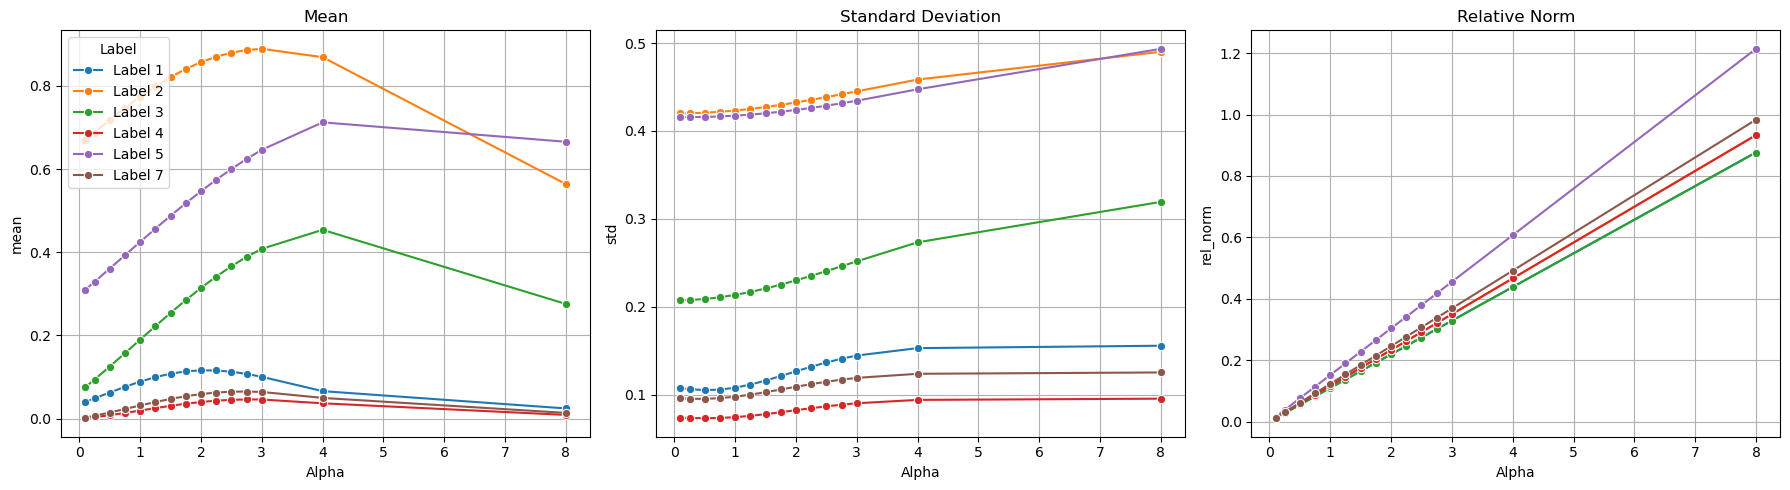

In [11]:
summary = (
    plot_df.groupby(["label", "alpha"], as_index=False)
           .agg(mean=("mean", "mean"),
                std=("std", "mean"),
                rel_norm=("rel_norm", "mean"))
)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, metric, title in zip(
    axes,
    ["mean", "std", "rel_norm"],
    ["Mean", "Standard Deviation", "Relative Norm"]
):
    sns.lineplot(
        data=summary,
        x="alpha",
        y=metric,
        hue="label",
        marker="o",
        ax=ax
    )
    ax.set_title(title)
    ax.set_xlabel("Alpha")
    ax.grid(True)
axes[1].legend_.remove()
axes[2].legend_.remove()
axes[0].legend(title="Label", loc="upper left")

plt.tight_layout()
plt.show()

In [12]:
def find_gp_direction(z0, gp, n=1000, beta=0.5, seed=42):
    rng = np.random.default_rng(seed)
    dirs = rng.normal(size=(n, z0.size))
    dirs /= np.linalg.norm(dirs, axis=1, keepdims=True)
    means, stds = gp.predict(z0 + dirs, return_std=True)
    return dirs[np.argmax(means - beta * stds)]
def make_gp_delta(z0, direction, alpha):
    z_new = z0 + alpha * direction

    z0_pca = best_scaler.inverse_transform(z0[None])
    z_new_pca = best_scaler.inverse_transform(z_new[None])

    x0 = best_pca.inverse_transform(z0_pca)[0]
    x_new = best_pca.inverse_transform(z_new_pca)[0]

    return x_new - x0
def make_steering_hook(delta_activation):
    delta = torch.as_tensor(
        delta_activation,
        dtype=model.dtype,
        device=model.device
    )

    def hook(module, inputs, output):
        if isinstance(output, tuple):
            hidden = output[0].clone()
            hidden[:, -1, :] += delta
            return (hidden,) + output[1:]

        hidden = output.clone()
        hidden[:, -1, :] += delta
        return hidden

    return hook

In [13]:
df = {"means": [], "uncertainty": []}
labels = [1, 2, 3, 4, 5, 7]
alpha = 3

for target_label in labels:
    mean_changes, uncertainty_changes = [], []
    gp = best_gps[target_label]

    for i in range(min(1000, len(Xte))):
        x0 = Xte[i]
        z_original = best_scaler.transform(best_pca.transform(x0[None]))
        z0 = z_original[0]

        direction = find_gp_direction(z0, gp)
        delta = make_gp_delta(z0, direction, alpha)
        x_steered = x0 + delta
        z_steered = best_scaler.transform(best_pca.transform(x_steered[None]))

        original_mean, original_std = gp.predict(z_original, return_std=True)
        steered_mean, steered_std = gp.predict(z_steered, return_std=True)

        mean_changes.append(steered_mean[0] - original_mean[0])
        uncertainty_changes.append(steered_std[0] - original_std[0])

    df["means"].append(mean_changes)
    df["uncertainty"].append(uncertainty_changes)

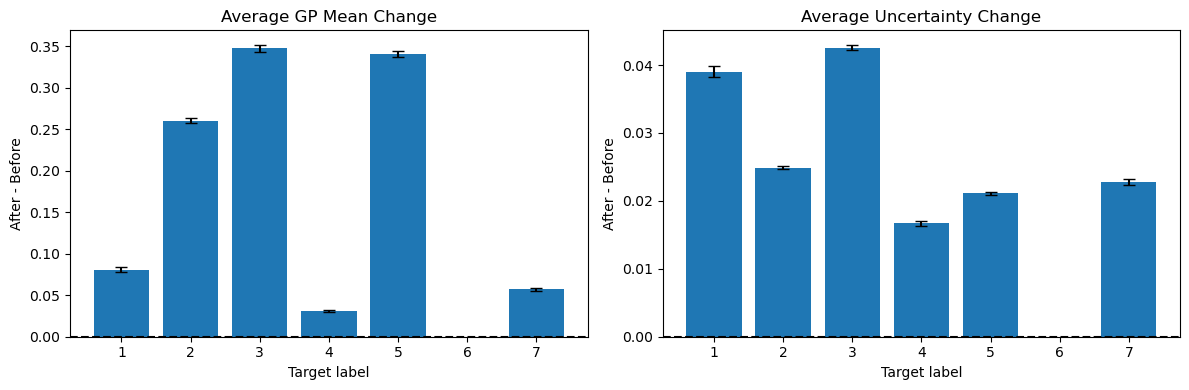

In [14]:


mean_avg = [np.mean(x) for x in df["means"]]
mean_std = [np.std(x) / np.sqrt(len(x)) for x in df["means"]]

unc_avg = [np.mean(x) for x in df["uncertainty"]]
unc_std = [np.std(x) / np.sqrt(len(x)) for x in df["uncertainty"]]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(labels, mean_avg, yerr=mean_std, capsize=4)
axes[1].bar(labels, unc_avg, yerr=unc_std, capsize=4)

axes[0].axhline(0, color="black", linestyle="--")
axes[1].axhline(0, color="black", linestyle="--")

axes[0].set(title="Average GP Mean Change", xlabel="Target label", ylabel="After - Before")
axes[1].set(title="Average Uncertainty Change", xlabel="Target label", ylabel="After - Before")

plt.tight_layout()
plt.show()

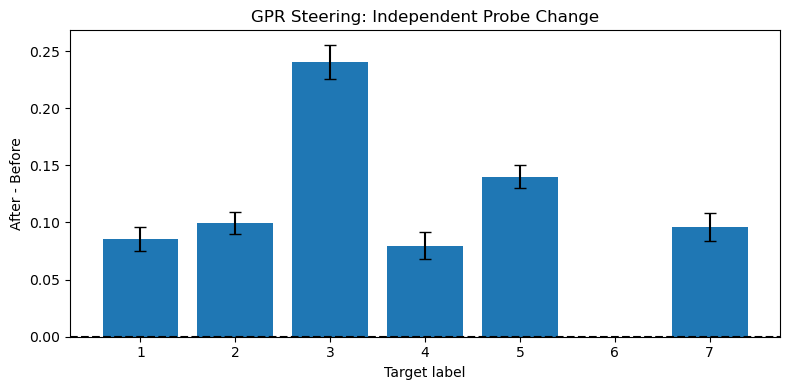

In [15]:
probe = joblib.load("../Probes/qwen14b-probes/qwen14b_best_linear_probe.pkl")

gpr_probe_changes = []

for target_label in labels:
    col = list(mlb.classes_).index(target_label)
    gp = best_gps[target_label]

    X_eval = Xte_small[Yte_small[:, col] == 0][:1000]
    before = probe.predict_proba(X_eval)[:, col]

    X_steered = []

    for x0 in X_eval:
        z0 = best_scaler.transform(best_pca.transform(x0[None]))[0]
        direction = find_gp_direction(z0, gp)
        delta = make_gp_delta(z0, direction, alpha)
        X_steered.append(x0 + delta)

    after = probe.predict_proba(np.asarray(X_steered))[:, col]
    gpr_probe_changes.append(after - before)

means = [np.mean(v) for v in gpr_probe_changes]
errors = [np.std(v) / np.sqrt(len(v)) for v in gpr_probe_changes]

plt.figure(figsize=(8, 4))
plt.bar(labels, means, yerr=errors, capsize=4)
plt.axhline(0, color="black", linestyle="--")
plt.title("GPR Steering: Independent Probe Change")
plt.xlabel("Target label")
plt.ylabel("After - Before")
plt.tight_layout()
plt.show()

In [16]:
beta = 0.5

gpr_norm = []
gpr_mean = []
gpr_uncertainty = []
gpr_utility = []
gpr_efficiency = []

for target_label in labels:
    gp = best_gps[target_label]

    norms = []
    mean_changes = []
    uncertainty_changes = []
    utility_changes = []
    efficiency_changes = []

    for x0 in Xte_small[:1000]:
        z0 = best_scaler.transform(best_pca.transform(x0[None]))[0]
        m0, s0 = gp.predict(z0[None], return_std=True)

        direction = find_gp_direction(z0, gp, beta=beta)
        delta = make_gp_delta(z0, direction, alpha)

        x1 = x0 + delta
        z1 = best_scaler.transform(best_pca.transform(x1[None]))
        m1, s1 = gp.predict(z1, return_std=True)

        norm = np.linalg.norm(delta)
        dmu = m1[0] - m0[0]
        dsigma = s1[0] - s0[0]

        norms.append(norm)
        mean_changes.append(dmu)
        uncertainty_changes.append(dsigma)
        utility_changes.append(dmu - beta * dsigma)
        efficiency_changes.append(dmu / max(norm, 1e-12))

    gpr_norm.append(np.mean(norms))
    gpr_mean.append(np.mean(mean_changes))
    gpr_uncertainty.append(np.mean(uncertainty_changes))
    gpr_utility.append(np.mean(utility_changes))
    gpr_efficiency.append(np.mean(efficiency_changes))


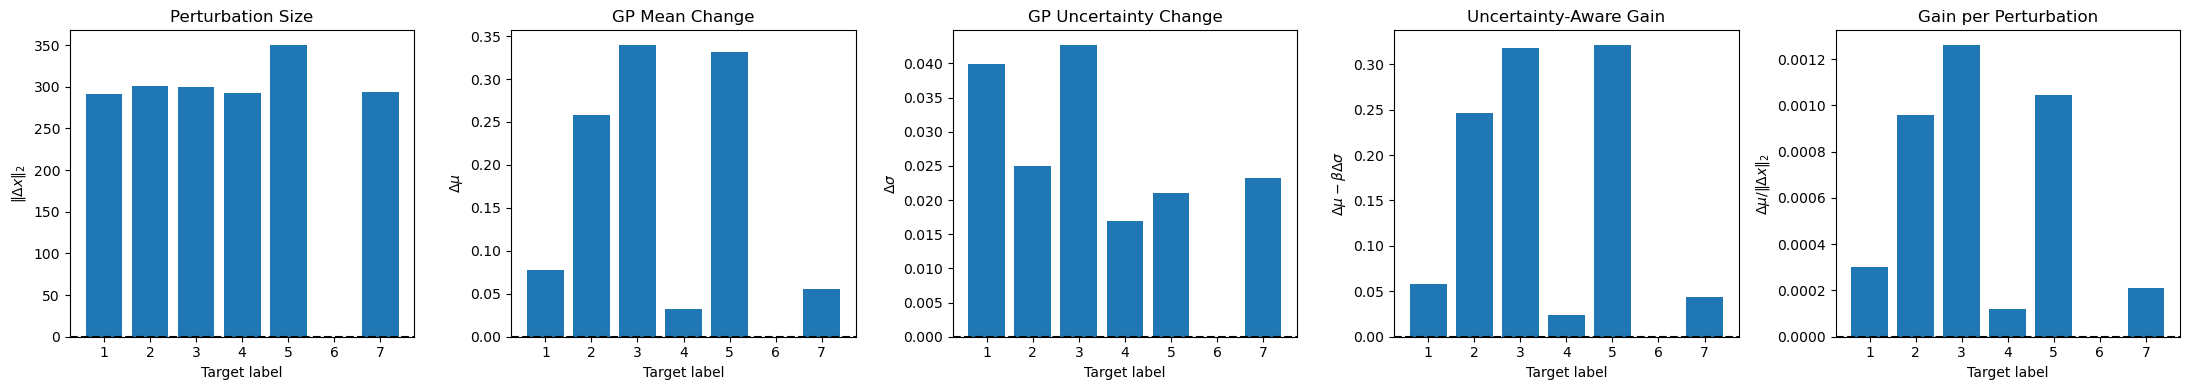

In [17]:
fig, axes = plt.subplots(1, 5, figsize=(22, 4))

values = [
    (gpr_norm, "Perturbation Size", r"$\|\Delta x\|_2$"),
    (gpr_mean, "GP Mean Change", r"$\Delta\mu$"),
    (gpr_uncertainty, "GP Uncertainty Change", r"$\Delta\sigma$"),
    (gpr_utility, "Uncertainty-Aware Gain",
     r"$\Delta\mu-\beta\Delta\sigma$"),
    (gpr_efficiency, "Gain per Perturbation",
     r"$\Delta\mu/\|\Delta x\|_2$")
]

for ax, (vals, title, ylabel) in zip(axes, values):
    ax.bar(labels, vals)
    ax.axhline(0, color="black", linestyle="--")
    ax.set_title(title)
    ax.set_xlabel("Target label")
    ax.set_ylabel(ylabel)

plt.tight_layout()
plt.show()

In [18]:
# | Target label | Perturbation norm | GP mean change | Uncertainty change | Uncertainty-aware gain | Gain per perturbation | Interpretation                     |
# | -----------: | ----------------: | -------------: | -----------------: | ---------------------: | --------------------: | ---------------------------------- |
# |            1 |               5.3 |           0.11 |              0.036 |                   0.09 |                 0.022 | Positive but modest steering       |
# |            2 |               5.6 |           0.26 |              0.023 |                   0.25 |                 0.046 | Strong and efficient               |
# |            3 |               5.4 |           0.23 |              0.037 |                   0.21 |                 0.043 | Strong, but uncertainty rises more |
# |            4 |               5.3 |           0.04 |              0.015 |                   0.04 |                 0.009 | Weakest steering                   |
# |            5 |               5.5 |           0.29 |              0.028 |                   0.27 |                 0.052 | Best overall                       |
# |            6 |                 — |              — |                  — |                      — |                     — | No visible result                  |
# |            7 |               5.3 |           0.08 |              0.024 |                   0.07 |                 0.015 | Positive but weak                  |


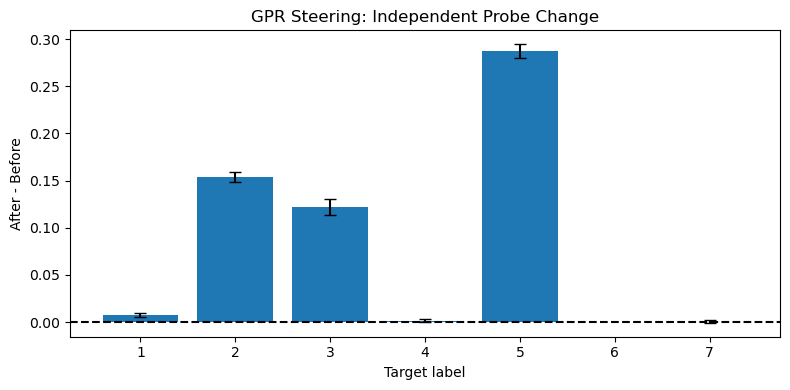

In [19]:
import joblib
import numpy as np
import matplotlib.pyplot as plt

probe = joblib.load("../Probes/qwen14b-probes/qwen14b_best_nonlinear_probe.pkl")

gpr_probe_changes = []

for target_label in labels:
    col = list(mlb.classes_).index(target_label)
    gp = best_gps[target_label]

    X_eval = Xte_small[Yte_small[:, col] == 0][:1000]
    before = probe.predict_proba(X_eval)[:, col]

    X_steered = []

    for x0 in X_eval:
        z0 = best_scaler.transform(best_pca.transform(x0[None]))[0]
        direction = find_gp_direction(z0, gp)
        delta = make_gp_delta(z0, direction, alpha)
        X_steered.append(x0 + delta)

    after = probe.predict_proba(np.asarray(X_steered))[:, col]
    gpr_probe_changes.append(after - before)

means = [np.mean(v) for v in gpr_probe_changes]
errors = [np.std(v) / np.sqrt(len(v)) for v in gpr_probe_changes]

plt.figure(figsize=(8, 4))
plt.bar(labels, means, yerr=errors, capsize=4)
plt.axhline(0, color="black", linestyle="--")
plt.title("GPR Steering: Independent Probe Change")
plt.xlabel("Target label")
plt.ylabel("After - Before")
plt.tight_layout()
plt.show()